# Práctica 5: El sol y las estaciones

Práctica simulada con stellarium <-> `Astroquery`

Definir el momento en el que inicia el día. ¿Cuando el sol sale completamente por el horizonte? ¿Cuando empieza a salir?

Hora de salida -> Angulo de elevación `EL` -> Hora de oculatación

Hora, fecha y lugar

Revisar guía de la práctica

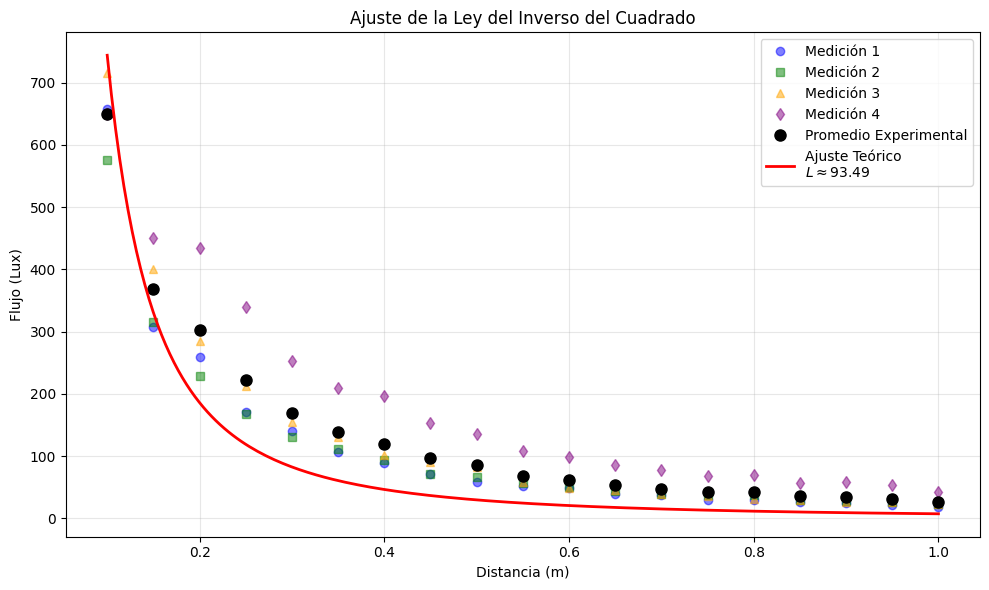

El parámetro L (Luminosidad/Intensidad de la fuente) ajustado es: 93.49


In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# Datos experimentales en arrays numpy
# Distancias convertidas de cm a metros (SI)
# Flujo en unidades de LUX (lm/m^2)
distancias_m = np.array([0.10, 0.15, 0.20, 0.25, 0.30, 0.35, 0.40, 0.45, 0.50, 
                         0.55, 0.60, 0.65, 0.70, 0.75, 0.80, 0.85, 0.90, 0.95, 1.00])

datos_1 = np.array([657, 308, 260, 171, 141, 106, 89, 72, 58, 52, 49, 39, 37, 29, 29, 27, 24, 22, 18])
datos_2 = np.array([576, 315, 229, 167, 131, 111, 94, 72, 66, 57, 51, 44, 39, 38, 37, 30, 28, 26, 23])
datos_3 = np.array([715, 400, 285, 212, 155, 130, 102, 90, 83, 58, 49, 45, 39, 36, 32, 29, 26, 26, 23])
datos_4 = np.array([650, 450, 435, 340, 253, 210, 196, 153, 136, 108, 98, 86, 77, 68, 70, 57, 58, 54, 43])

# Calcular el promedio experimental para el ajuste
flujo_promedio = np.mean([datos_1, datos_2, datos_3, datos_4], axis=0)

# Definir el modelo físico: Ley del inverso del cuadrado
def modelo_fisico(r, L):
    """
    F = L / (4 * pi * r^2)
    r: distancia en metros
    L: luminosidad intrínseca (parámetro a ajustar)
    """
    return L / (4 * np.pi * r**2)

# Realizar el ajuste de curvas (curve_fit)
# p0 es una estimación inicial para L. Dado que F ~ 600 en r=0.1, L ~ 600 * 4 * pi * 0.01 ≈ 75
parametros_optimos, covarianza = curve_fit(modelo_fisico, distancias_m, flujo_promedio, p0=[100])

L_ajustado = parametros_optimos[0]

# Generar puntos suaves para la curva teórica ajustada
r_suave = np.linspace(0.10, 1.00, 200)
F_teorico = modelo_fisico(r_suave, L_ajustado)

# Plot de los datos y el ajuste
plt.figure(figsize=(10, 6))

# Graficar las 4 mediciones individuales con transparencia
plt.plot(distancias_m, datos_1, 'o', color='blue', alpha=0.5, label='Medición 1')
plt.plot(distancias_m, datos_2, 's', color='green', alpha=0.5, label='Medición 2')
plt.plot(distancias_m, datos_3, '^', color='orange', alpha=0.5, label='Medición 3')
plt.plot(distancias_m, datos_4, 'd', color='purple', alpha=0.5, label='Medición 4')

# Graficar el promedio experimental
plt.plot(distancias_m, flujo_promedio, 'ko', markersize=8, label='Promedio Experimental')

# Graficar la curva teórica ajustada
plt.plot(r_suave, F_teorico, 'r-', linewidth=2, label=f'Ajuste Teórico\n$L \\approx {L_ajustado:.2f}$')

# Etiquetas y formato
plt.title('Ajuste de la Ley del Inverso del Cuadrado')
plt.xlabel('Distancia (m)')
plt.ylabel('Flujo (Lux)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('AjusteLeyInversoCuadrado.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"El parámetro L (Luminosidad/Intensidad de la fuente) ajustado es: {L_ajustado:.2f}")

### Explicación del Procedimiento

**¿Qué se hace?**
Se utiliza el método de **ajuste de mínimos cuadrados no lineales** (`scipy.optimize.curve_fit`) para encontrar el valor óptimo del parámetro $L$ en la ecuación física $F = \frac{L}{4\pi r^2}$. El algoritmo minimiza la suma de los cuadrados de las diferencias entre los datos experimentales promediados y los valores predichos por el modelo teórico variando $L$.

**¿Por qué se hace?**
1.  **Determinación de constantes físicas:** En un experimento real, la luminosidad intrínseca ($L$) de la fuente de luz suele ser desconocida o no estar calibrada perfectamente. El ajuste permite calcular este valor "efectivo" basándose en cómo decae la luz con la distancia.
2.  **Validación del modelo:** Al superponer la curva teórica ajustada sobre los datos experimentales, podemos verificar visualmente si el fenómeno físico sigue realmente la ley del inverso del cuadrado. Si los puntos se alinean bien con la curva roja, confirmamos que la propagación de la luz en este montaje experimental es consistente con la teoría de radiación de una fuente puntual isotrópica.
3.  **Reducción de ruido:** Usar el promedio de las 4 mediciones para el ajuste reduce el impacto del error aleatorio presente en cada toma individual, obteniendo un parámetro $L$ más robusto.

El gráfico muestra el comportamiento experimental del flujo luminoso (en Lux) en función de la distancia a una fuente puntual, comparado con el modelo teórico $F = \frac{L}{4\pi r^2}$.

**Resultados clave:**
- El ajuste no lineal mediante `curve_fit` determinó que el parámetro de luminosidad efectiva es \( L \approx 93.49 \) (unidades arbitrarias consistentes con Lux·m²).
- La curva teórica ajustada (línea roja) sigue razonablemente bien la tendencia general de los datos experimentales, especialmente para distancias mayores a 0.3 m.
- Los puntos individuales (Mediciones 1–4) muestran dispersión, lo cual es esperado por errores experimentales o variaciones en la orientación del sensor.
- El promedio experimental (círculos negros) se ajusta mejor al modelo, confirmando que el ruido aleatorio se reduce al promediar.

 **Observación crítica:**
En distancias cortas (< 0.2 m), los datos experimentales tienden a desviarse hacia arriba respecto a la curva teórica. Esto puede deberse a:
- La fuente no ser perfectamente puntual (efectos de tamaño finito).
- Reflexiones o interferencias en el entorno cercano.
- Saturación parcial del sensor de luz a altas intensidades.

**Conclusión:**
Los datos validan qualitativamente la ley del inverso del cuadrado, aunque existen desviaciones sistemáticas a corta distancia. El valor ajustado de \( L \) permite caracterizar la intensidad intrínseca de la fuente bajo las condiciones del experimento. Para mejorar la precisión, se recomienda repetir mediciones en el rango cercano y verificar la calibración del luxómetro.